In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os, sys
import pickle
import pandas as pd
import numpy as np
sys.path.append('../src')

import utils

# Move tables
In this notebook we want to do the second step that is necessary to start transforming the data gathered into something that can be used for analysis, which is creating move tables.

Move tables will include all the moves performed in the analysed game, and will allow for further analysis of the data. In particular, we're interested in loading the data from the `data/analysis` folder.

We must first take the game data.

## Load data

In [81]:
# basic parameters
username = 'rugitodoleao_returns'
years = [2023]
months = [1, 2]

### Load raw data

In [4]:
# load player data
player_data_raw = utils.load_player_data(
    username,
    years,
    months,
    outdir = "../data/player_data",
    force = False
)

### Postprocess game metadata

In [9]:
# create a dataframe containing all the info we need
# for the analysis
player_data = utils.postprocess_data(player_data_raw, username)

In [13]:
player_data.iloc[0]

rating_white                                                     1011
result_white                                                      win
@id_white           https://api.chess.com/pub/player/gaspard_the_best
username_white                                       Gaspard_the_Best
uuid_white                       5e744ff6-cdf2-11e3-8060-000000000000
rating_black                                                      934
result_black                                                 resigned
@id_black           https://api.chess.com/pub/player/rugitodoleao_...
username_black                                   rugitodoleao_returns
uuid_black                       dc1822f6-17e1-11ed-8ff2-2b370c364d20
url                       https://www.chess.com/game/live/66301833501
pgn                 [Event "Live Chess"]\n[Site "Chess.com"]\n[Dat...
time_control                                                      180
end_time                                                   1672563064
rated               

### Load analysis data

In [14]:
%%time

# general analysis parameters
depth = 20
multipv = 3
outdir = "../data/analysis"
analysis_outdir = utils.analysis_outdir_name(depth, multipv, outdir)

# init data structure
analysis_data = pd.Series(index=player_data.index, dtype=object)

for fname in os.listdir(analysis_outdir):
    
    # name of the file we read
    full_fname = f"{analysis_outdir}/{fname}"
    
    # game identifier
    gameid = fname.replace(".pkl", "")
    
    # read file
    with open(full_fname, 'rb') as f:
        analysis_data[gameid] = pickle.load(f)[1]

CPU times: user 5.58 s, sys: 160 ms, total: 5.74 s
Wall time: 5.74 s


## Make move tables

In [15]:
%%time
# init the table as a list
move_table = []

# iterate on the games
for gameid, pgn in player_data.pgn.items():
    tmp = utils.create_move_table(pgn, analysis_data)
    move_table.append(tmp)
    
# and then create a master dataframe
move_table = pd.concat(move_table)

CPU times: user 9.28 s, sys: 5.18 ms, total: 9.28 s
Wall time: 9.28 s


In [16]:
# load openings
openings = utils.load_openings('../data/chess-openings/dist')
openings.head()

,eco,name,pgn,uci,epd
0,A00,Amar Gambit,1. Nh3 d5 2. g3 e5 3. f4 Bxh3 4. Bxh3 exf4,g1h3 d7d5 g2g3 e7e5 f2f4 c8h3 f1h3 e5f4,rn1qkbnr/ppp2ppp/8/3p4/5p2/6PB/PPPPP2P/RNBQK2R...
1,A00,Amar Opening,1. Nh3,g1h3,rnbqkbnr/pppppppp/8/8/8/7N/PPPPPPPP/RNBQKB1R b...
2,A00,Amar Opening: Gent Gambit,1. Nh3 d5 2. g3 e5 3. f4 Bxh3 4. Bxh3 exf4 5. ...,g1h3 d7d5 g2g3 e7e5 f2f4 c8h3 f1h3 e5f4 e1g1 f...,rn1qkbnr/ppp2ppp/8/3p4/8/6PB/PPPPP3/RNBQ1RK1 b...
3,A00,Amar Opening: Paris Gambit,1. Nh3 d5 2. g3 e5 3. f4,g1h3 d7d5 g2g3 e7e5 f2f4,rnbqkbnr/ppp2ppp/8/3pp3/5P2/6PN/PPPPP2P/RNBQKB...
4,A00,Amsterdam Attack,1. e3 e5 2. c4 d6 3. Nc3 Nc6 4. b3 Nf6,e2e3 e7e5 c2c4 d7d6 b1c3 b8c6 b2b3 g8f6,r1bqkb1r/ppp2ppp/2np1n2/4p3/2P5/1PN1P3/P2P1PPP...


In [18]:
%%time
analysis_df = move_table.groupby('gameid').apply(utils.classify_moves, openings=openings)# .apply(pd.Series)

# results
move_table_expanded = move_table.merge(analysis_df, on='move_id',how='left')

CPU times: user 1min 43s, sys: 1min 5s, total: 2min 49s
Wall time: 2min 49s


In [33]:
player_moves = move_table_expanded.merge(\
                player_data['color'].reset_index(), on=['gameid', 'color'])

In [52]:
game_data = move_table_expanded.iloc[:40]

In [53]:
game_data.merge(openings, on='epd').tail(1).iloc[0]

move_id                                               66301833501-1
gameid                                                  66301833501
ply                                                               1
move_number                                                       1
color                                                         black
piece                                                             P
uci_x                                                          c7c6
san                                                              c6
epd               rnbqkbnr/pp1ppppp/2p5/8/4P3/8/PPPP1PPP/RNBQKBN...
fen               rnbqkbnr/pp1ppppp/2p5/8/4P3/8/PPPP1PPP/RNBQKBN...
analysis_data     [{'string': 'NNUE evaluation using nn-ad9b4235...
classification                                                 good
cp                                                               29
accuracy                                                  83.353678
cp_loss                                         

<AxesSubplot:xlabel='move_number'>

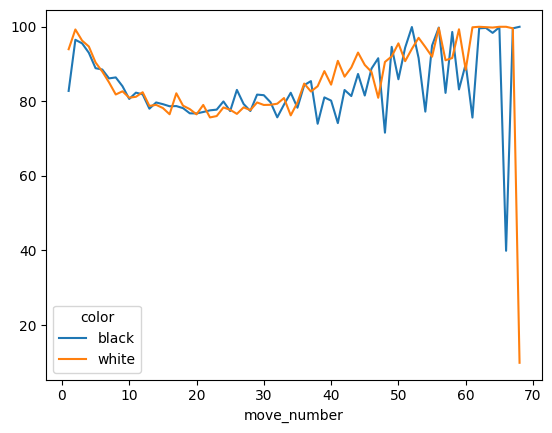

In [67]:
player_moves.groupby(['color', 'move_number']).accuracy.mean().dropna().unstack().transpose().plot()

<AxesSubplot:xlabel='move_number'>

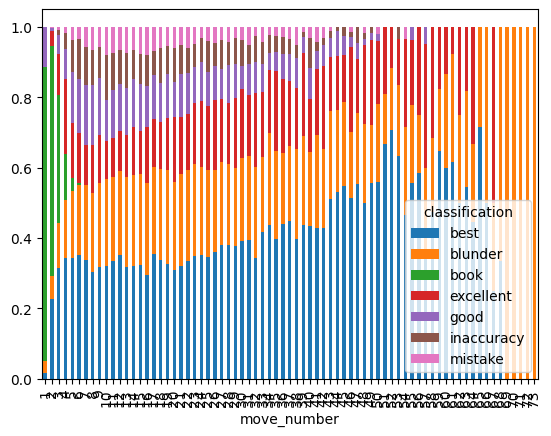

In [80]:
classification_move_number = player_moves.\
   groupby(['classification', 'move_number']).move_id.nunique().\
   unstack().transpose()

nmoves_move_number = classification_move_number.sum(axis=1)

classification_move_number.divide(nmoves_move_number, axis=0).plot(kind='bar',stacked=True)

In [48]:
player_moves.merge(player_data['opening'], left_index=True,
                   right_index=True)# .query('classification != "book"').groupby('opening').accuracy

KeyError: 'opening'